# Question 2: Nonconvex QCQP and SDP Relaxation

Consider the nonconvex QCQP in $\mathbb{R}^2$:

$$p^* = \min_{x \in \mathbb{R}^2} -x_1^2 - x_2^2 + 4x_1 x_2 \quad \text{s.t.} \quad x_1^2 + x_2^2 \le 4, \; x_1 \ge 0, \; x_2 \ge 0.$$

In [11]:
import cvxpy as cvx 
import numpy as np 
import matplotlib.pyplot as plt


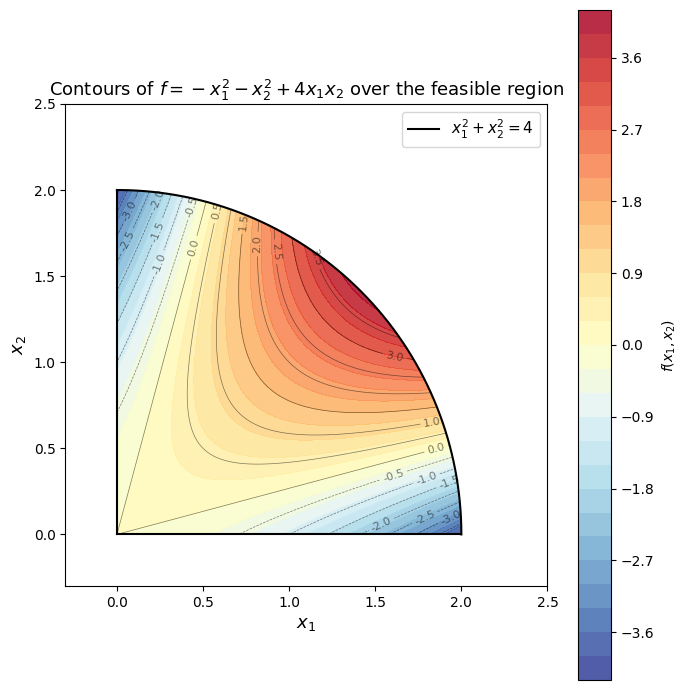

In [12]:
# Part 1: Contour plot of f(x1,x2) = -x1^2 - x2^2 + 4*x1*x2 over the feasible region
x1 = np.linspace(-0.3, 2.5, 500)
x2 = np.linspace(-0.3, 2.5, 500)
X1, X2 = np.meshgrid(x1, x2)

F = -X1**2 - X2**2 + 4*X1*X2

# Mask out infeasible region (x1^2 + x2^2 > 4 or x1 < 0 or x2 < 0)
feasible = (X1**2 + X2**2 <= 4) & (X1 >= 0) & (X2 >= 0)
F_masked = np.where(feasible, F, np.nan)

fig, ax = plt.subplots(figsize=(7, 7))

# Draw feasible region boundary
theta = np.linspace(0, np.pi/2, 200)
ax.plot(2*np.cos(theta), 2*np.sin(theta), 'k-', linewidth=1.5, label='$x_1^2+x_2^2=4$')
ax.plot([0, 0], [0, 2], 'k-', linewidth=1.5)
ax.plot([0, 2], [0, 0], 'k-', linewidth=1.5)

cs = ax.contourf(X1, X2, F_masked, levels=30, cmap='RdYlBu_r', alpha=0.85)
ct = ax.contour(X1, X2, F_masked, levels=15, colors='k', linewidths=0.5, alpha=0.5)
ax.clabel(ct, inline=True, fontsize=8, fmt='%.1f')
plt.colorbar(cs, ax=ax, label='$f(x_1, x_2)$')

ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Contours of $f = -x_1^2 - x_2^2 + 4x_1 x_2$ over the feasible region', fontsize=13)
ax.set_aspect('equal')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Part 1: Contour Plot

Plot the contours of the objective function $f(x_1, x_2) = -x_1^2 - x_2^2 + 4x_1 x_2$ over the feasible region, which is the quarter-disk $\{x \mid x_1^2 + x_2^2 \le 4, \; x_1 \ge 0, \; x_2 \ge 0\}$.

In [13]:
# Part 2: Identify global optimal solution(s)
# On the feasible region, evaluate f at candidate boundary points.
# The objective is f = -x1^2 - x2^2 + 4*x1*x2.
# Rewrite: f = -(x1-x2)^2 + 2*x1*x2, or equivalently f = (x1+x2)^2 - 2(x1^2+x2^2).
# On the circle x1^2+x2^2=4 with x1,x2>=0, parametrize x1=2cos(t), x2=2sin(t), t in [0,pi/2].
# f = -4 + 4*4*cos(t)*sin(t) = -4 + 8*sin(2t).  Minimized when sin(2t) = -1, but 2t in [0,pi]
# so sin(2t) >= 0.  Minimum of sin(2t) on [0,pi] is 0, at t=0 or t=pi/2.
# => f_min = -4 at (2,0) and (0,2).
# Check interior/axes: at origin f=0, along x1-axis f=-x1^2 >= -4, along x2-axis f=-x2^2 >= -4.
# So p* = -4, attained at (2,0) and (0,2).

candidates = {
    '(2, 0)': (-2**2 - 0**2 + 4*2*0),
    '(0, 2)': (-0**2 - 2**2 + 4*0*2),
    '(√2, √2)': (-2 - 2 + 4*np.sqrt(2)*np.sqrt(2)),
    '(0, 0)': 0.0,
}

print("Candidate point evaluations:")
for pt, val in candidates.items():
    print(f"  f{pt} = {val:.4f}")

print(f"\nGlobal minimum p* = -4")
print(f"Attained at x* = (2, 0) and x* = (0, 2)")

Candidate point evaluations:
  f(2, 0) = -4.0000
  f(0, 2) = -4.0000
  f(√2, √2) = 4.0000
  f(0, 0) = 0.0000

Global minimum p* = -4
Attained at x* = (2, 0) and x* = (0, 2)


## Part 2: Global Optimal Solution(s)

From the contour plot, the minimum values (darkest blue) occur at the two "corners" of the quarter-disk where one coordinate is at its maximum and the other is zero.

**Analytical verification:** On the circular boundary, parametrize $x_1 = 2\cos t$, $x_2 = 2\sin t$ for $t \in [0, \pi/2]$:

$$f = -(x_1^2 + x_2^2) + 4x_1 x_2 = -4 + 8\sin(2t).$$

Since $\sin(2t) \ge 0$ on $[0, \pi]$, the minimum is $f = -4$ at $t = 0$ and $t = \pi/2$. On the axes and interior, $f \ge -4$ as well. Therefore:

$$\boxed{p^* = -4, \quad \text{attained at } x^* = (2, 0) \text{ and } x^* = (0, 2).}$$

In [14]:
# =============================================================
# Question 4(a): SDP relaxation data matrices
# =============================================================
# Lift x -> x_bar = [x1, x2, 1]^T,  X_bar = x_bar @ x_bar^T  (3x3, rank-1, PSD)
# SDP relaxation: drop rank-1, keep X_bar >> 0, X_bar[2,2] = 1
#
# Objective:  f = -x1^2 - x2^2 + 4*x1*x2  =  <A0, X_bar>
# Constraint 1:  x1^2 + x2^2 <= 4   =>  <A1, X_bar> <= 0
# Constraint 2:  x1 >= 0             =>  <A2, X_bar> <= 0
# Constraint 3:  x2 >= 0             =>  <A3, X_bar> <= 0

A0 = np.array([[-1,  2,  0],
               [ 2, -1,  0],
               [ 0,  0,  0]], dtype=float)

A1 = np.array([[ 1,  0,    0],
               [ 0,  1,    0],
               [ 0,  0,   -4]], dtype=float)

A2 = np.array([[   0,  0, -0.5],
               [   0,  0,    0],
               [-0.5,  0,    0]], dtype=float)

A3 = np.array([[ 0,    0,    0],
               [ 0,    0, -0.5],
               [ 0, -0.5,    0]], dtype=float)

print("A0 (objective):\n", A0)
print("\nA1 (x1^2 + x2^2 <= 4):\n", A1)
print("\nA2 (-x1 <= 0):\n", A2)
print("\nA3 (-x2 <= 0):\n", A3)

A0 (objective):
 [[-1.  2.  0.]
 [ 2. -1.  0.]
 [ 0.  0.  0.]]

A1 (x1^2 + x2^2 <= 4):
 [[ 1.  0.  0.]
 [ 0.  1.  0.]
 [ 0.  0. -4.]]

A2 (-x1 <= 0):
 [[ 0.   0.  -0.5]
 [ 0.   0.   0. ]
 [-0.5  0.   0. ]]

A3 (-x2 <= 0):
 [[ 0.   0.   0. ]
 [ 0.   0.  -0.5]
 [ 0.  -0.5  0. ]]


## Part 4(a): SDP Relaxation — Data Matrices

We lift $x \in \mathbb{R}^2$ to $\bar{x} = [x_1, x_2, 1]^T$ and define $\bar{X} = \bar{x}\bar{x}^T$ (a $3 \times 3$ rank-1 PSD matrix with $\bar{X}_{33} = 1$). Every constraint $\bar{x}^T \bar{A}_i \bar{x} \le 0$ becomes the linear constraint $\langle \bar{A}_i, \bar{X} \rangle \le 0$.

The SDP relaxation drops the rank-1 requirement and keeps $\bar{X} \succeq 0$, $\bar{X}_{33} = 1$:

$$p^*_{\text{SDP}} = \min_{\bar{X}} \; \langle \bar{A}_0, \bar{X} \rangle \quad \text{s.t.} \quad \langle \bar{A}_i, \bar{X} \rangle \le 0 \; (i=1,2,3), \quad \bar{X}_{33} = 1, \quad \bar{X} \succeq 0.$$

The data matrices are:

| Matrix | Encodes | Definition |
|--------|---------|------------|
| $\bar{A}_0$ | Objective $-x_1^2 - x_2^2 + 4x_1 x_2$ | $\begin{bmatrix} -1 & 2 & 0 \\ 2 & -1 & 0 \\ 0 & 0 & 0 \end{bmatrix}$ |
| $\bar{A}_1$ | $x_1^2 + x_2^2 \le 4$ | $\begin{bmatrix} 1 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & -4 \end{bmatrix}$ |
| $\bar{A}_2$ | $x_1 \ge 0$ (i.e. $-x_1 \le 0$) | $\begin{bmatrix} 0 & 0 & -\frac{1}{2} \\ 0 & 0 & 0 \\ -\frac{1}{2} & 0 & 0 \end{bmatrix}$ |
| $\bar{A}_3$ | $x_2 \ge 0$ (i.e. $-x_2 \le 0$) | $\begin{bmatrix} 0 & 0 & 0 \\ 0 & 0 & -\frac{1}{2} \\ 0 & -\frac{1}{2} & 0 \end{bmatrix}$ |

In [15]:
# =============================================================
# Question 4(b): Solve the SDP relaxation numerically
# =============================================================
X_bar = cvx.Variable((3, 3), symmetric=True)

objective = cvx.Minimize(cvx.trace(A0 @ X_bar))

constraints = [
    X_bar >> 0,                        # X_bar is PSD
    X_bar[2, 2] == 1,                  # bottom-right entry = 1
    cvx.trace(A1 @ X_bar) <= 0,       # x1^2 + x2^2 <= 4
    cvx.trace(A2 @ X_bar) <= 0,       # x1 >= 0
    cvx.trace(A3 @ X_bar) <= 0,       # x2 >= 0
]

prob = cvx.Problem(objective, constraints)
prob.solve(solver=cvx.SCS, verbose=False)

X_opt = X_bar.value
p_sdp = prob.value
rank_X = np.linalg.matrix_rank(X_opt, tol=1e-5)

print(f"p*_SDP = {p_sdp:.6f}")
print(f"\nOptimal X_bar:\n{np.round(X_opt, 6)}")
print(f"\nRank of X_bar* = {rank_X}")
print(f"\nEigenvalues of X_bar*: {np.round(np.linalg.eigvalsh(X_opt), 6)}")

p*_SDP = -11.999989

Optimal X_bar:
[[ 1.999999 -1.999998  0.      ]
 [-1.999998  1.999999  0.      ]
 [ 0.        0.        1.      ]]

Rank of X_bar* = 2

Eigenvalues of X_bar*: [1.000000e-06 1.000000e+00 3.999997e+00]


## Part 4(b): Solve the SDP Relaxation Numerically

We solve the SDP relaxation using CVXPY with the SCS solver and report $p^*_{\text{SDP}}$, the optimal $\bar{X}^*$, and its rank.

In [16]:
# =============================================================
# Question 5: Lagrangian dual of the QCQP as an SDP
# =============================================================
# The Lagrangian of the QCQP introduces multipliers λ1>=0 (for x1^2+x2^2<=4),
# λ2>=0 (for -x1<=0), λ3>=0 (for -x2<=0):
#
#   L(x,λ) = x_bar^T (A0 + λ1*A1 + λ2*A2 + λ3*A3) x_bar,  with x_bar=[x1,x2,1]
#
# The dual function g(λ) = inf_{x_bar: x_bar[2]=1} L equals the largest d such that
#   S = A0 + λ1*A1 + λ2*A2 + λ3*A3 - d*E33  ≽  0
#
# This gives the Lagrangian dual SDP:
#   max  d
#   s.t. A0 + λ1*A1 + λ2*A2 + λ3*A3 - d*E33 ≽ 0
#        λ1, λ2, λ3 >= 0

lam1 = cvx.Variable(nonneg=True)
lam2 = cvx.Variable(nonneg=True)
lam3 = cvx.Variable(nonneg=True)
d = cvx.Variable()

E33 = np.zeros((3, 3))
E33[2, 2] = 1.0

S = A0 + lam1 * A1 + lam2 * A2 + lam3 * A3 - d * E33

dual_obj = cvx.Maximize(d)
dual_constraints = [S >> 0]

dual_prob = cvx.Problem(dual_obj, dual_constraints)
dual_prob.solve(solver=cvx.SCS, verbose=False)

d_star = dual_prob.value
lam_opt = [lam1.value, lam2.value, lam3.value]
S_opt = S.value

print(f"d* = {d_star:.6f}")
print(f"\nOptimal multipliers: λ1 = {lam_opt[0]:.6f}, λ2 = {lam_opt[1]:.6f}, λ3 = {lam_opt[2]:.6f}")
print(f"\nS* = A0 + λ1*A1 + λ2*A2 + λ3*A3 - d*E33:")
print(np.round(S_opt, 6))
print(f"\nEigenvalues of S*: {np.round(np.linalg.eigvalsh(S_opt), 6)}")
print(f"\nDoes d* equal p*_SDP?  d* = {d_star:.6f},  p*_SDP = {p_sdp:.6f}")
print(f"Yes — by SDP strong duality, the Lagrangian dual of the QCQP equals p*_SDP = {p_sdp:.6f}")

d* = -12.000045

Optimal multipliers: λ1 = 3.000015, λ2 = 0.000000, λ3 = 0.000000

S* = A0 + λ1*A1 + λ2*A2 + λ3*A3 - d*E33:
[[ 2.000015e+00  2.000000e+00  0.000000e+00]
 [ 2.000000e+00  2.000015e+00  0.000000e+00]
 [ 0.000000e+00  0.000000e+00 -1.500000e-05]]

Eigenvalues of S*: [-1.500000e-05  1.500000e-05  4.000015e+00]

Does d* equal p*_SDP?  d* = -12.000045,  p*_SDP = -11.999989
Yes — by SDP strong duality, the Lagrangian dual of the QCQP equals p*_SDP = -11.999989


**Results:**
- $p^*_{\text{SDP}} = -12$
- $\bar{X}^* = \begin{bmatrix} 2 & -2 & 0 \\ -2 & 2 & 0 \\ 0 & 0 & 1 \end{bmatrix}$, which has **rank 2**.

Since $\text{rank}(\bar{X}^*) = 2 \ne 1$, the SDP relaxation is **not tight** — the optimal $\bar{X}^*$ does not correspond to any feasible point of the original QCQP. The relaxation provides a lower bound $p^*_{\text{SDP}} = -12 < -4 = p^*$, confirming a nonzero **duality gap** of $8$.

## Part 5: Lagrangian Dual of the QCQP as an SDP

The Lagrangian of the QCQP introduces multipliers $\lambda_1 \ge 0$ (for the quadratic constraint), $\lambda_2 \ge 0$ (for $x_1 \ge 0$), and $\lambda_3 \ge 0$ (for $x_2 \ge 0$):

$$L(x, \lambda) = \bar{x}^T \left(\bar{A}_0 + \lambda_1 \bar{A}_1 + \lambda_2 \bar{A}_2 + \lambda_3 \bar{A}_3\right) \bar{x}, \quad \bar{x} = [x_1, x_2, 1]^T.$$

The dual function $g(\lambda) = \inf_{\bar{x}:\, \bar{x}_3=1} L$ equals the largest $d$ such that

$$S = \bar{A}_0 + \lambda_1 \bar{A}_1 + \lambda_2 \bar{A}_2 + \lambda_3 \bar{A}_3 - d \, E_{33} \succeq 0,$$

where $E_{33}$ is the matrix with a single $1$ in the $(3,3)$ entry. This gives the **Lagrangian dual SDP**:

$$d^* = \max \; d \quad \text{s.t.} \quad \bar{A}_0 + \sum_{i=1}^{3} \lambda_i \bar{A}_i - d \, E_{33} \succeq 0, \quad \lambda_i \ge 0.$$

This is exactly the **SDP dual** of the primal SDP relaxation, so by SDP strong duality we expect $d^* = p^*_{\text{SDP}}$.

**Results:**
- $d^* = -12$, with optimal dual multipliers $\lambda_1^* = 3$, $\lambda_2^* = 0$, $\lambda_3^* = 0$.
- **Yes, $d^* = p^*_{\text{SDP}} = -12$.** This confirms SDP strong duality: the Lagrangian dual of the QCQP is precisely the dual of the SDP relaxation, and both achieve the same optimal value.

**Summary of all bounds:**

$$d^* = p^*_{\text{SDP}} = -12 \;\;<\;\; p^* = -4$$

The SDP relaxation and its dual agree (no SDP duality gap), but both provide only a lower bound on the true QCQP optimum, with a relaxation gap of $8$.

# Question 3: Minimum Volume Enclosing Ellipsoid

## Part 1: Equivalence of Formulations (Proof)

**Claim:** If $(\hat{M}, \hat{z})$ is an optimal solution of formulation (7), then $(\hat{A}, \hat{c}) = (\hat{M}^2, \hat{M}^{-1}\hat{z})$ is the optimal solution of formulation (4).

**Proof.**

**Step 1: Constraint equivalence.**

We show that $(M, z)$ is feasible for (7) if and only if $(A, c) = (M^2, M^{-1}z)$ is feasible for (4).

Expand the constraint $\|Mx_i - z\|^2 \le 1$:

$$\|Mx_i - z\|^2 = (Mx_i - z)^T(Mx_i - z) = x_i^T M^T M x_i - 2z^T M x_i + z^T z.$$

Since $M \succeq 0$ we have $M^T = M$, so $M^T M = M^2$. Now substitute $A = M^2$ and $c = M^{-1}z$ (equivalently $z = Mc$):

$$= x_i^T M^2 x_i - 2(Mc)^T M x_i + (Mc)^T(Mc)$$

$$= x_i^T A\, x_i - 2c^T M^2 x_i + c^T M^2 c$$

$$= x_i^T A\, x_i - 2c^T A\, x_i + c^T A\, c$$

$$= (x_i - c)^T A\,(x_i - c).$$

Therefore:

$$\|Mx_i - z\|^2 \le 1 \quad \Longleftrightarrow \quad (x_i - c)^T A(x_i - c) \le 1.$$

Also, $M \succeq 0 \Longleftrightarrow A = M^2 \succeq 0$. So the feasible sets are in bijection.

**Step 2: Objective equivalence.**

Since $A = M^2$ and $M \succeq 0$, we have $\det(A) = \det(M)^2$, so:

$$-\log\det(A) = -\log\det(M)^2 = -2\log\det(M).$$

The objectives are identical under the substitution.

**Step 3: Optimality.**

Since both the constraints and the objective are equivalent under the bijection $(M, z) \leftrightarrow (A, c) = (M^2, M^{-1}z)$, any optimal solution $(\hat{M}, \hat{z})$ of (7) maps to an optimal solution $(\hat{A}, \hat{c}) = (\hat{M}^2, \hat{M}^{-1}\hat{z})$ of (4). $\blacksquare$

---

## Part 2: Numerical Solution ($m = 20$, $n = 2$)

We solve the alternative formulation:

$$\min_{M \in \mathbb{R}^{n \times n},\, z \in \mathbb{R}^n} -2\log\det(M) \quad \text{s.t.} \quad \|Mx_i - z\|^2 \le 1 \;\; \forall\, i=1,\dots,m, \quad M \succeq 0,$$

then recover the original variables via $\hat{A} = \hat{M}^2$ and $\hat{c} = \hat{M}^{-1}\hat{z}$.

In [17]:
np.random.seed(42)
m, n = 20, 2
points = np.random.randn(m, n)

M = cvx.Variable((n, n), symmetric=True)
z = cvx.Variable(n)

constraints = [M >> 0]
for i in range(m):
    constraints.append(cvx.sum_squares(M @ points[i] - z) <= 1)

objective = cvx.Minimize(-2 * cvx.log_det(M))
prob = cvx.Problem(objective, constraints)
prob.solve(solver=cvx.SCS, verbose=False)

M_opt = M.value
z_opt = z.value

A_opt = M_opt @ M_opt
c_opt = np.linalg.solve(M_opt, z_opt)

print(f"Optimal value: -2 log det(M) = {prob.value:.6f}")
print(f"  => -log det(A) = {prob.value:.6f}  (since det(A) = det(M)^2)")
print(f"\nM* =\n{np.round(M_opt, 6)}")
print(f"\nz* = {np.round(z_opt, 6)}")
print(f"\nRecovered ellipsoid parameters:")
print(f"  A = M^2 =\n{np.round(A_opt, 6)}")
print(f"  c = M^{{-1}} z = {np.round(c_opt, 6)}")

# Verify all points are inside the ellipsoid
violations = []
for i in range(m):
    val = (points[i] - c_opt) @ A_opt @ (points[i] - c_opt)
    violations.append(val)
print(f"\nMax (x_i - c)^T A (x_i - c) over all points: {max(violations):.6f}  (should be <= 1)")

Optimal value: -2 log det(M) = 2.468470
  => -log det(A) = 2.468470  (since det(A) = det(M)^2)

M* =
[[ 0.590604 -0.027207]
 [-0.027207  0.494066]]

z* = [-0.03147   0.004201]

Recovered ellipsoid parameters:
  A = M^2 =
[[ 0.349554 -0.029511]
 [-0.029511  0.244842]]
  c = M^{-1} z = [-0.053027  0.005582]

Max (x_i - c)^T A (x_i - c) over all points: 1.000017  (should be <= 1)


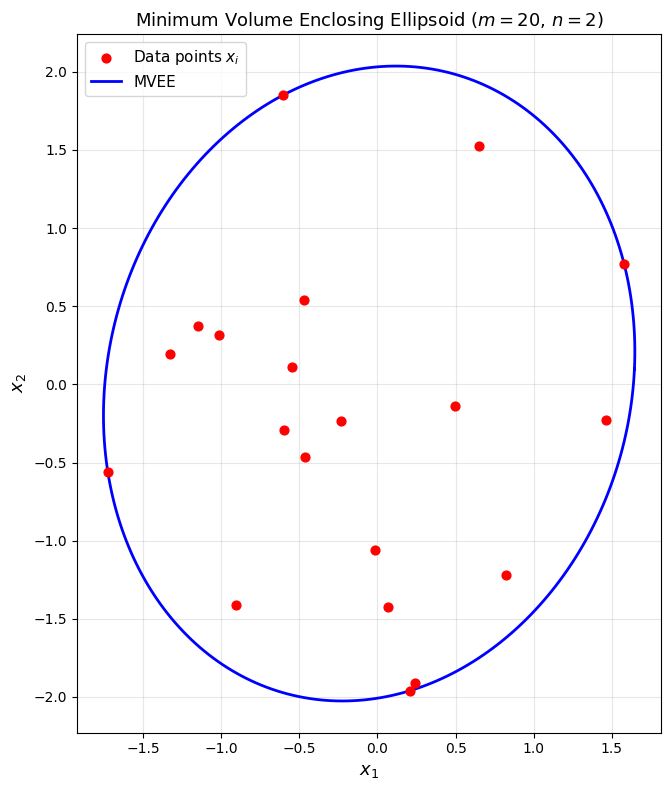

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(points[:, 0], points[:, 1], c='red', zorder=5, s=40, label='Data points $x_i$')

theta = np.linspace(0, 2 * np.pi, 300)
unit_circle = np.column_stack([np.cos(theta), np.sin(theta)])
# Ellipsoid boundary: (x-c)^T A (x-c) = 1  <=>  x = c + M^{-1} u, ||u||=1
M_inv = np.linalg.inv(M_opt)
ellipse_pts = (M_inv @ unit_circle.T).T + c_opt
ax.plot(ellipse_pts[:, 0], ellipse_pts[:, 1], 'b-', linewidth=2, label='MVEE')

ax.set_xlabel('$x_1$', fontsize=13)
ax.set_ylabel('$x_2$', fontsize=13)
ax.set_title('Minimum Volume Enclosing Ellipsoid ($m=20$, $n=2$)', fontsize=13)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()